In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# Update paths after downloading from Kaggle
train_df = pd.read_csv('training_set_features.csv')
labels_df = pd.read_csv('training_set_labels.csv')
test_df = pd.read_csv('test_set_features.csv')
submission_df = pd.read_csv('submission_format.csv')

train_df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,age_group,education,income_poverty,sex
0,1,2,1,1,1,4,5,35 - 44 Years,12 Years,Middle,Male
1,2,3,2,0,0,2,1,45 - 54 Years,<12 Years,Below Poverty,Male
2,3,0,0,0,0,2,2,35 - 44 Years,12 Years,Middle,Female
3,4,2,0,0,1,5,5,35 - 44 Years,12 Years,Below Poverty,Male
4,5,2,0,1,0,3,5,18 - 34 Years,College Graduate,Middle,Female


In [ ]:
# Basic info and missing values
train_df.info()
train_df.isnull().sum().sort_values(ascending=False).head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   respondent_id                1000 non-null   int64 
 1   h1n1_concern                 1000 non-null   int64 
 2   h1n1_knowledge               1000 non-null   int64 
 3   behavioral_antiviral_meds    1000 non-null   int64 
 4   behavioral_avoidance         1000 non-null   int64 
 5   opinion_h1n1_vacc_effective  1000 non-null   int64 
 6   opinion_h1n1_risk            1000 non-null   int64 
 7   age_group                    1000 non-null   object
 8   education                    1000 non-null   object
 9   income_poverty               1000 non-null   object
 10  sex                          1000 non-null   object
dtypes: int64(7), object(4)
memory usage: 86.1+ KB


,0
respondent_id,0
h1n1_concern,0
h1n1_knowledge,0
behavioral_antiviral_meds,0
behavioral_avoidance,0
opinion_h1n1_vacc_effective,0
opinion_h1n1_risk,0
age_group,0
education,0
income_poverty,0


In [ ]:
# Merge features and labels for analysis
df = pd.merge(train_df, labels_df, on='respondent_id')
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,age_group,education,income_poverty,sex,h1n1_vaccine,seasonal_vaccine
0,1,2,1,1,1,4,5,35 - 44 Years,12 Years,Middle,Male,1,1
1,2,3,2,0,0,2,1,45 - 54 Years,<12 Years,Below Poverty,Male,1,0
2,3,0,0,0,0,2,2,35 - 44 Years,12 Years,Middle,Female,0,1
3,4,2,0,0,1,5,5,35 - 44 Years,12 Years,Below Poverty,Male,0,1
4,5,2,0,1,0,3,5,18 - 34 Years,College Graduate,Middle,Female,1,1


In [ ]:
df['h1n1_vaccine'].value_counts()

,count
h1n1_vaccine,
1,506
0,494


In [ ]:
df['seasonal_vaccine'].value_counts()

,count
seasonal_vaccine,
0,504
1,496


In [ ]:
# Merging feature and target data
df = train_df.merge(labels_df, how='left', on='respondent_id')
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,age_group,education,income_poverty,sex,h1n1_vaccine,seasonal_vaccine
0,1,2,1,1,1,4,5,35 - 44 Years,12 Years,Middle,Male,1,1
1,2,3,2,0,0,2,1,45 - 54 Years,<12 Years,Below Poverty,Male,1,0
2,3,0,0,0,0,2,2,35 - 44 Years,12 Years,Middle,Female,0,1
3,4,2,0,0,1,5,5,35 - 44 Years,12 Years,Below Poverty,Male,0,1
4,5,2,0,1,0,3,5,18 - 34 Years,College Graduate,Middle,Female,1,1


In [ ]:
# Getting info about null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   respondent_id                1000 non-null   int64 
 1   h1n1_concern                 1000 non-null   int64 
 2   h1n1_knowledge               1000 non-null   int64 
 3   behavioral_antiviral_meds    1000 non-null   int64 
 4   behavioral_avoidance         1000 non-null   int64 
 5   opinion_h1n1_vacc_effective  1000 non-null   int64 
 6   opinion_h1n1_risk            1000 non-null   int64 
 7   age_group                    1000 non-null   object
 8   education                    1000 non-null   object
 9   income_poverty               1000 non-null   object
 10  sex                          1000 non-null   object
 11  h1n1_vaccine                 1000 non-null   int64 
 12  seasonal_vaccine             1000 non-null   int64 
dtypes: int64(9), object(4)
memory usag

In [ ]:
# Getting number of null values
df.isna().sum()

,0
respondent_id,0
h1n1_concern,0
h1n1_knowledge,0
behavioral_antiviral_meds,0
behavioral_avoidance,0
opinion_h1n1_vacc_effective,0
opinion_h1n1_risk,0
age_group,0
education,0
income_poverty,0


In [ ]:
# Explore numerical columns
df.describe()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,h1n1_vaccine,seasonal_vaccine
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1.534000,0.98700,0.513000,0.526000,3.044000,2.976000,0.506000,0.496000
std,288.819436,1.151595,0.81823,0.500081,0.499573,1.424814,1.419662,0.500214,0.500234
min,1.000000,0.000000,0.00000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,250.750000,0.000000,0.00000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,500.500000,2.000000,1.00000,1.000000,1.000000,3.000000,3.000000,1.000000,0.000000
75%,750.250000,3.000000,2.00000,1.000000,1.000000,4.000000,4.000000,1.000000,1.000000
max,1000.000000,3.000000,2.00000,1.000000,1.000000,5.000000,5.000000,1.000000,1.000000


In [ ]:
# Explore object columns
df[[c for c in df.columns if df[c].dtype =='object']].describe()

,age_group,education,income_poverty,sex
count,1000,1000,1000,1000
unique,5,4,3,2
top,55 - 64 Years,12 Years,Middle,Female
freq,209,267,349,506


# EDA

In [ ]:
# Making a copy of main dataframe to use for visualizations
df2 = df.copy()

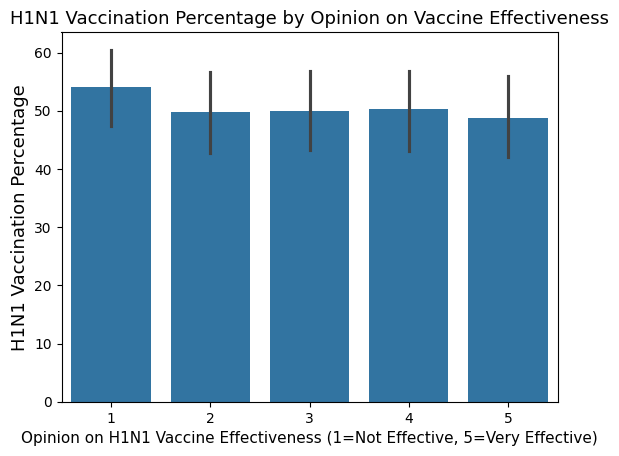

In [ ]:
df2 = df.copy()
# Graph for relationship between H1N1 vaccination and opinion on H1N1 vaccine effectiveness
dr = sns.barplot(x=df2['opinion_h1n1_vacc_effective'].dropna(), y=df2['h1n1_vaccine']*100)
dr.set_xlabel('Opinion on H1N1 Vaccine Effectiveness (1=Not Effective, 5=Very Effective)', fontsize=11)
dr.set_ylabel('H1N1 Vaccination Percentage', fontsize=13)
dr.set_title('H1N1 Vaccination Percentage by Opinion on Vaccine Effectiveness', fontsize=13);

In [ ]:
# Creating dictionary for mapping in order to create better names for x axis in graphs below
ins_dict = {1: 'seasonal_vaccine',
           0: ' No seasonal_vaccine'}

In [ ]:
# Creating the column that will be used to create clear x axis tick marks in graph below
df2['health_ins_words'] = df2['seasonal_vaccine'].replace(ins_dict)

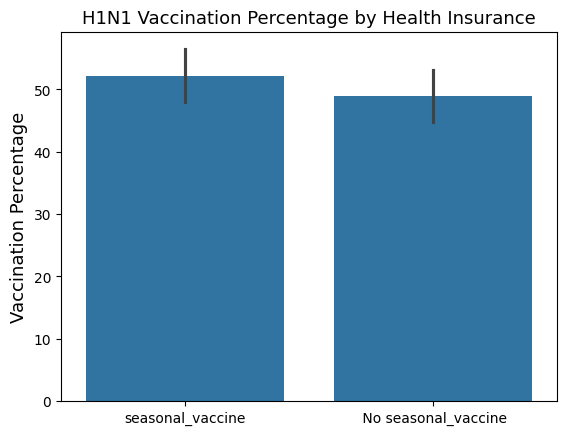

In [ ]:
# Health Insurance graph
ins = sns.barplot(x=df2['health_ins_words'], y=df2['h1n1_vaccine']*100)
ins.set_xlabel('')
ins.set_ylabel('Vaccination Percentage', fontsize=13)
ins.set_title('H1N1 Vaccination Percentage by Health Insurance', fontsize=13);

/tmp/ipython-input-299263492.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ins = sns.barplot(x=df2['opinion_h1n1_vacc_effective'].dropna(), y=df2['h1n1_vaccine']*100, palette='viridis')


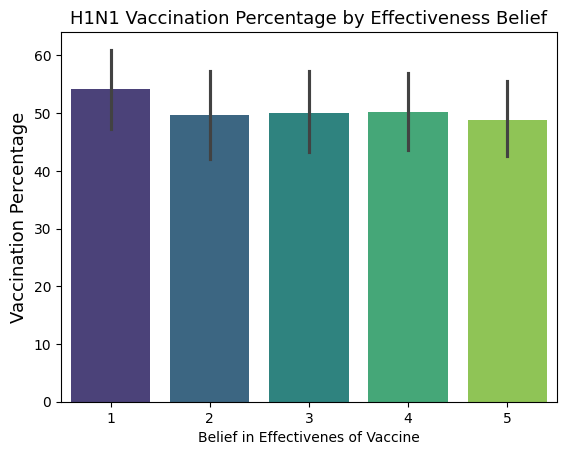

In [ ]:
# Graph for vaccine percentage differrentiation depending on opinion of effectiveness of H1N1 Vaccine
ins = sns.barplot(x=df2['opinion_h1n1_vacc_effective'].dropna(), y=df2['h1n1_vaccine']*100, palette='viridis')
ins.set_xlabel('Belief in Effectivenes of Vaccine')
ins.set_ylabel('Vaccination Percentage', fontsize=13)
ins.set_title('H1N1 Vaccination Percentage by Effectiveness Belief', fontsize=13);

/tmp/ipython-input-3397304430.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ins = sns.barplot(x=df2['opinion_h1n1_risk'].dropna(), y=df2['h1n1_vaccine']*100, palette='magma')


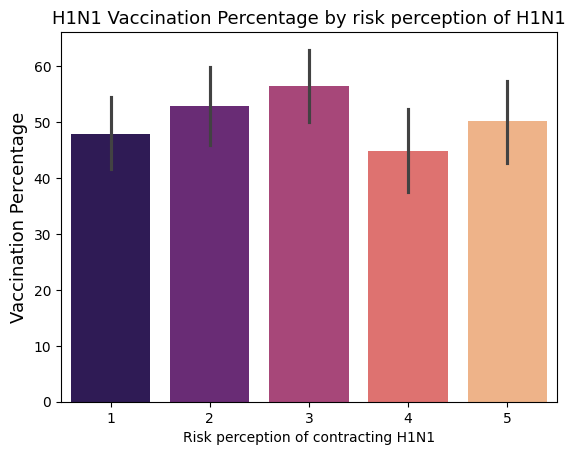

In [ ]:
# Risk graph exploring vaccine percentage depending on risk perception of H1N1
ins = sns.barplot(x=df2['opinion_h1n1_risk'].dropna(), y=df2['h1n1_vaccine']*100, palette='magma')
ins.set_xlabel('Risk perception of contracting H1N1')
ins.set_ylabel('Vaccination Percentage', fontsize=13)
ins.set_title('H1N1 Vaccination Percentage by risk perception of H1N1', fontsize=13);

#Data Preparation

In [ ]:
# Define our X and y
X = df.drop(columns = ['respondent_id', 'h1n1_vaccine', 'seasonal_vaccine'], axis=1)
y = df['h1n1_vaccine']

In [ ]:
# Train - Holdout Set Split
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

In [ ]:
# Regular Train Test Split
X_tr, X_te, y_tr, y_te = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

In [ ]:
# Set up lists for each columns datatypes
num_cols = []
ohe_cols = []
freq_cols = []

for c in X.columns:
    if X[c].dtype in ['float64', 'int64']:
        num_cols.append(c)
    elif X[c].nunique() < 10:
        ohe_cols.append(c)
    else:
        freq_cols.append(c)

In [ ]:
# We wanted to see each column category
print(f'Numerical Columns:', num_cols)
print('\n')
print(f'Object Columns (with less than 10 unique values):', ohe_cols)
print('\n')
print(f'Object Columns (with more than 10 unique values):', freq_cols)

Numerical Columns: ['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds', 'behavioral_avoidance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk']


Object Columns (with less than 10 unique values): ['age_group', 'education', 'income_poverty', 'sex']


Object Columns (with more than 10 unique values): []


In [ ]:
!pip install category_encoders
from sklearn.experimental import enable_iterative_imputer
from sklearn.pipeline import Pipeline
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
import category_encoders as ce

# Preprocessing with Pipelines
num_transformer = Pipeline(steps=[
    ('num_imputer', IterativeImputer(max_iter=100, random_state=42)),   # replace missing values by IterativeImputer
    ('minmaxscaler', MinMaxScaler())                                    # Scale the numbers by MinMaxScaler
])

ohe_transformer = Pipeline(steps=[
    ('ohe_imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),  # replace missing categories by SimpleImputer
    ('ohe_encoder', OneHotEncoder(handle_unknown='ignore'))                     # Transform each category into a new column
])

freq_transformer = Pipeline(steps=[
    ('freq_encoder', ce.CountEncoder(normalize=True, min_group_size=.05)), # replace category names with frequency counts by CountEncoder
    ('freq_imputer', IterativeImputer(max_iter=100, random_state=42))            # replace missing values by IterativeImputer
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.7 MB/s eta 0:00:00


In [ ]:
from sklearn.compose import ColumnTransformer
# Preprocessor defined using ColumnTransformer by packaging the all components together
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('ohe', ohe_transformer, ohe_cols),
        ('freq', freq_transformer, freq_cols)
    ])

In [ ]:
# Fitting preprocessor to see the components as a whole
preprocessor.fit(X_tr)


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('num_imputer',
                                                  IterativeImputer(max_iter=100,
                                                                   random_state=42)),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 ['h1n1_concern', 'h1n1_knowledge',
                                  'behavioral_antiviral_meds',
                                  'behavioral_avoidance',
                                  'opinion_h1n1_vacc_effective',
                                  'opinion_h1n1_risk']),
                                ('ohe',
                                 Pipeline(steps=[('ohe_imputer',
                                                  SimpleImputer(fill_value='Unknown',
                                                                strategy='constant')),
                                                 ('ohe_encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['age_group', 'education', 'income_poverty',
                                  'sex']),
                                ('freq',
                                 Pipeline(steps=[('freq_encoder',
                                                  CountEncoder(combine_min_nan_groups=True,
                                                               min_group_size=0.05,
                                                               normalize=True)),
                                                 ('freq_imputer',
                                                  IterativeImputer(max_iter=100,
                                                                   random_state=42))]),
                                 [])])

In [ ]:
# Let'see what this looks like after the preprocessor transformation
X_tr_transformed = preprocessor.transform(X_tr)
X_tr_transformed.shape

(720, 20)

In [ ]:
# Visualize it with Pandas dataframe
pd.DataFrame(X_tr_transformed).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.0,0.5,0.0,1.0,0.75,0.50,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,0.0,0.5,0.0,1.0,0.75,0.50,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,1.0,1.0,1.0,0.0,0.50,0.25,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3,1.0,1.0,1.0,1.0,1.00,0.75,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,0.0,0.5,0.0,1.0,0.75,1.00,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


#Modeling

##MODEL 1: Decision Tree Classifier

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Setting up the DecisionTreeClassifier to go though the pipeline
dtc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(class_weight='balanced', max_depth = 5))
])

In [ ]:
# fitting the model to the training data
dtc.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe_i...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'income_poverty', 'sex']),
                                                 ('freq',
                                                  Pipeline(steps=[('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                min_group_size=0.05,
                                                                                normalize=True)),
                                                                  ('freq_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42))]),
                                                  [])])),
                ('classifier',
                 DecisionTreeClassifier(class_weight='balanced', max_depth=5))])

--- Training Metrics ---
Accuracy: 0.6639
Precision: 0.6694
Recall: 0.6621
F1-Score: 0.6657

--- Test Metrics ---
Accuracy: 0.4833
Precision: 0.4904
Recall: 0.5604
F1-Score: 0.5231

--- Confusion Matrix (Test Set) ---


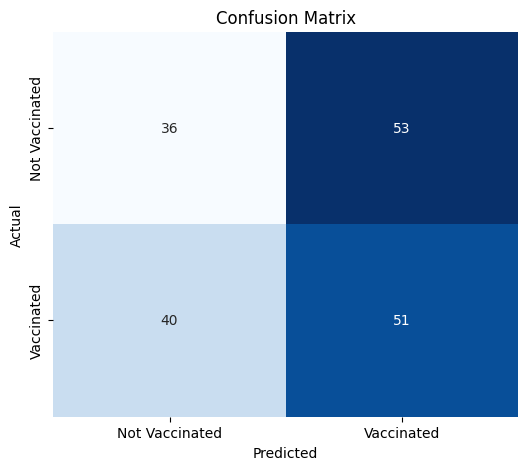


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.47      0.40      0.44        89
           1       0.49      0.56      0.52        91

    accuracy                           0.48       180
   macro avg       0.48      0.48      0.48       180
weighted avg       0.48      0.48      0.48       180



In [ ]:
# Evaluating the decision tree model for various metrics
evaluate(dtc, X_tr, X_te, y_tr, y_te, roc_auc='skip')

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate(model, X_train, X_test, y_train, y_test, roc_auc='calculate'):
    print('--- Training Metrics ---')
    y_pred_train = model.predict(X_train)
    print(f'Accuracy: {accuracy_score(y_train, y_pred_train):.4f}')
    print(f'Precision: {precision_score(y_train, y_pred_train):.4f}')
    print(f'Recall: {recall_score(y_train, y_pred_train):.4f}')
    print(f'F1-Score: {f1_score(y_train, y_pred_train):.4f}')
    if roc_auc == 'calculate':
        y_prob_train = model.predict_proba(X_train)[:, 1]
        print(f'ROC AUC: {roc_auc_score(y_train, y_prob_train):.4f}')

    print('\n--- Test Metrics ---')
    y_pred_test = model.predict(X_test)
    print(f'Accuracy: {accuracy_score(y_test, y_pred_test):.4f}')
    print(f'Precision: {precision_score(y_test, y_pred_test):.4f}')
    print(f'Recall: {recall_score(y_test, y_pred_test):.4f}')
    print(f'F1-Score: {f1_score(y_test, y_pred_test):.4f}')
    if roc_auc == 'calculate':
        y_prob_test = model.predict_proba(X_test)[:, 1]
        print(f'ROC AUC: {roc_auc_score(y_test, y_prob_test):.4f}')

    print('\n--- Confusion Matrix (Test Set) ---')
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Not Vaccinated', 'Vaccinated'],
                yticklabels=['Not Vaccinated', 'Vaccinated'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print('\n--- Classification Report (Test Set) ---')
    print(classification_report(y_test, y_pred_test))



--- Training Metrics ---
Accuracy: 0.6639
Precision: 0.6694
Recall: 0.6621
F1-Score: 0.6657

--- Test Metrics ---
Accuracy: 0.4833
Precision: 0.4904
Recall: 0.5604
F1-Score: 0.5231

--- Confusion Matrix (Test Set) ---


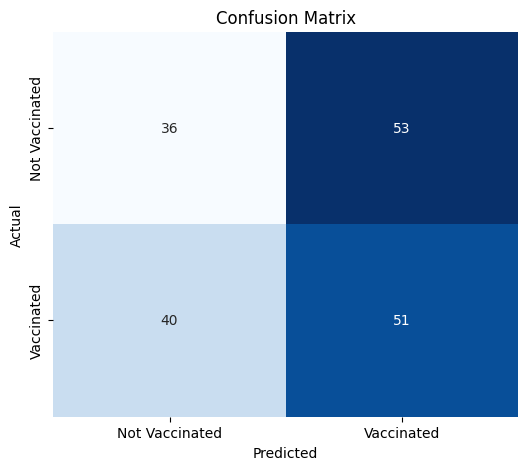


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.47      0.40      0.44        89
           1       0.49      0.56      0.52        91

    accuracy                           0.48       180
   macro avg       0.48      0.48      0.48       180
weighted avg       0.48      0.48      0.48       180



In [ ]:
# Evaluating the decision tree model for various metrics
evaluate(dtc, X_tr, X_te, y_tr, y_te, roc_auc='skip')

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

def plot_roc_curve(model, X_test, y_test, name, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
    ax.plot([0, 1], [0, 1], 'k--', label='Chance Level')
    ax.set_title(f'ROC Curve for {name}')
    ax.legend()
    plt.grid(linestyle='--', alpha=0.7)
    # Do not call plt.show() here if ax is provided, to allow multiple plots
    if ax is None:
        plt.show()

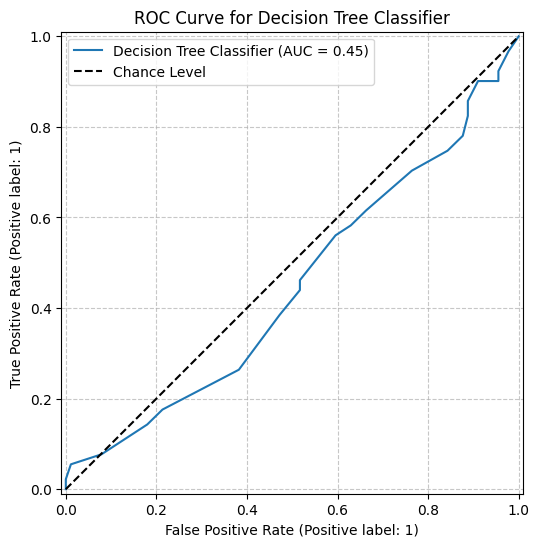

In [ ]:
# roc-auc curve for decision tree model
plot_roc_curve(dtc, X_te, y_te, name='Decision Tree Classifier');

##MODEL 2: Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

# Setting up the logistic regression model to go through the pipeline
logreg = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=500, C=1, class_weight= 'balanced', solver= 'lbfgs',
                                      random_state=42))
])


In [ ]:
# Fitting the logistic regression model on the training data
logreg.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe_i...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'income_poverty', 'sex']),
                                                 ('freq',
                                                  Pipeline(steps=[('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                min_group_size=0.05,
                                                                                normalize=True)),
                                                                  ('freq_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42))]),
                                                  [])])),
                ('classifier',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=500,
                                    random_state=42))])

--- Training Metrics ---
Accuracy: 0.5597
Precision: 0.5644
Recall: 0.5659
F1-Score: 0.5652
ROC AUC: 0.5958

--- Test Metrics ---
Accuracy: 0.4722
Precision: 0.4783
Recall: 0.4835
F1-Score: 0.4809
ROC AUC: 0.4226

--- Confusion Matrix (Test Set) ---


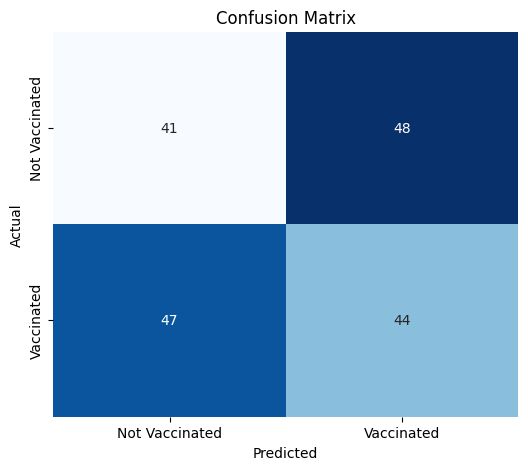


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.47      0.46      0.46        89
           1       0.48      0.48      0.48        91

    accuracy                           0.47       180
   macro avg       0.47      0.47      0.47       180
weighted avg       0.47      0.47      0.47       180



In [ ]:
# Evaluating the logistic regression for various metrics
evaluate(logreg, X_tr, X_te, y_tr, y_te)

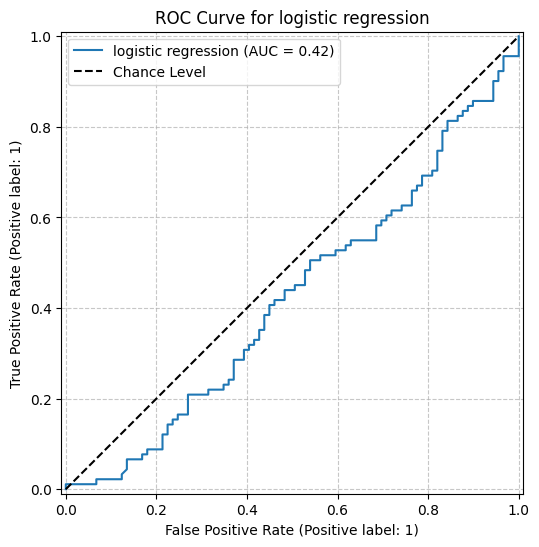

In [ ]:
# Plotting the roc-auc curve for the logistic regression model
plot_roc_curve(logreg, X_te, y_te, name='logistic regression');

##MODEL 3: Random Forest

In [ ]:
# Setting up the RandomForestClassifier to go through the pipeline
rfc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight= 'balanced', max_depth= 5, min_samples_leaf= 1,
                                          n_estimators= 200, random_state=42))
])

In [ ]:
# Fitting the random forest model to the training data
rfc.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe_i...
                                                  ['age_group', 'education',
                                                   'income_poverty', 'sex']),
                                                 ('freq',
                                                  Pipeline(steps=[('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                min_group_size=0.05,
                                                                                normalize=True)),
                                                                  ('freq_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42))]),
                                                  [])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=5,
                                        n_estimators=200, random_state=42))])

--- Training Metrics ---
Accuracy: 0.7806
Precision: 0.7641
Recall: 0.8187
F1-Score: 0.7905
ROC AUC: 0.8643

--- Test Metrics ---
Accuracy: 0.4500
Precision: 0.4592
Recall: 0.4945
F1-Score: 0.4762
ROC AUC: 0.4665

--- Confusion Matrix (Test Set) ---


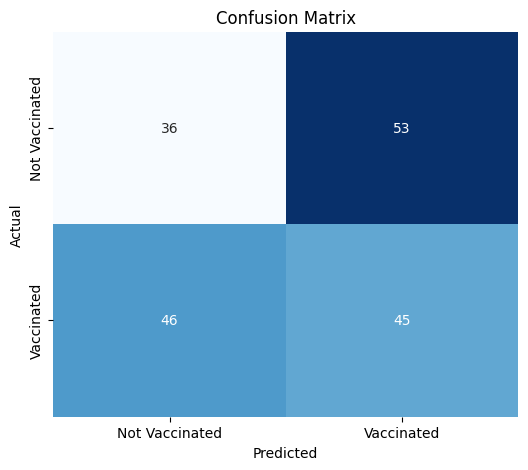


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.44      0.40      0.42        89
           1       0.46      0.49      0.48        91

    accuracy                           0.45       180
   macro avg       0.45      0.45      0.45       180
weighted avg       0.45      0.45      0.45       180



In [ ]:
# Evaluating various metrics of the random forest classifier
evaluate(rfc, X_tr, X_te, y_tr, y_te)

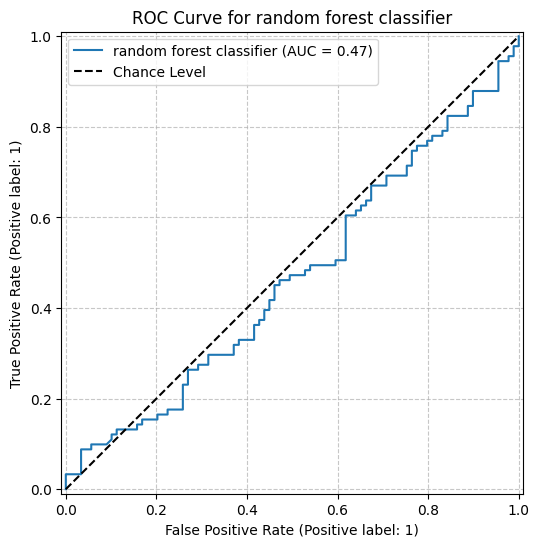

In [ ]:
plot_roc_curve(rfc, X_te, y_te, name='random forest classifier');

##MODEL 4: kNN Classifier

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

# Setting up the KNN model to go through the pipeline
kNN = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5, p=1, weights= 'distance'))
])

In [ ]:
# Fitting the KNN model to the training data
kNN.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe_i...
                                                                  ('ohe_encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'income_poverty', 'sex']),
                                                 ('freq',
                                                  Pipeline(steps=[('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                min_group_size=0.05,
                                                                                normalize=True)),
                                                                  ('freq_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42))]),
                                                  [])])),
                ('classifier', KNeighborsClassifier(p=1, weights='distance'))])

--- Training Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC: 1.0000

--- Test Metrics ---
Accuracy: 0.5389
Precision: 0.5426
Recall: 0.5604
F1-Score: 0.5514
ROC AUC: 0.5394

--- Confusion Matrix (Test Set) ---


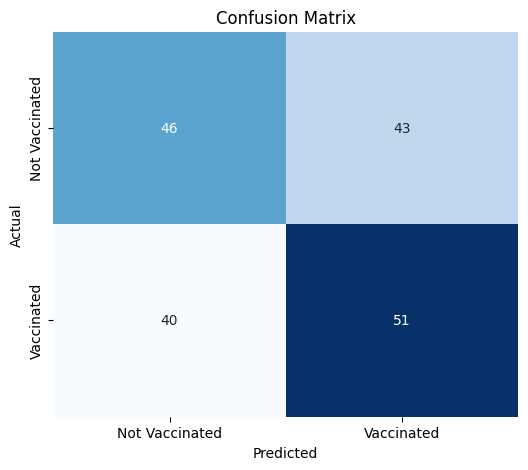


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.53      0.52      0.53        89
           1       0.54      0.56      0.55        91

    accuracy                           0.54       180
   macro avg       0.54      0.54      0.54       180
weighted avg       0.54      0.54      0.54       180



In [ ]:
# evaluating the KNN model for various metrics
evaluate(kNN, X_tr, X_te, y_tr, y_te)

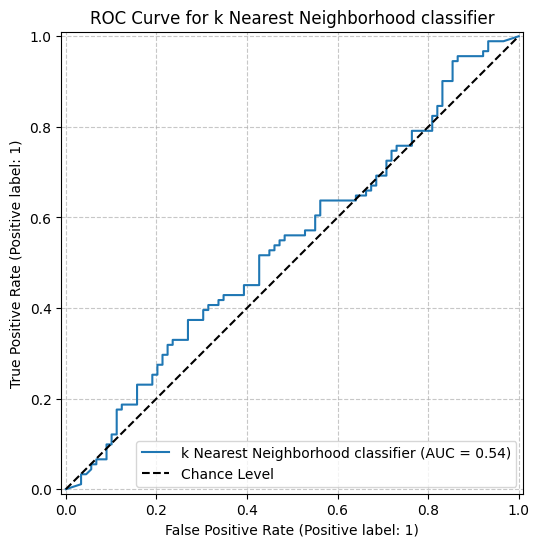

In [ ]:
# Plotting the roc-auc curve for the KNN model
plot_roc_curve(kNN, X_te, y_te, name='k Nearest Neighborhood classifier');

##MODEL 5: Gradient Boosting Classifier

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Setting up the gradient boosting classifier to go through the pipeline
gbc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(learning_rate= 0.1, max_depth= 5, n_estimators= 200,
        random_state=42))
])

In [ ]:
# Fitting the gradient boosting classifier to the training data
gbc.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe_i...
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'education',
                                                   'income_poverty', 'sex']),
                                                 ('freq',
                                                  Pipeline(steps=[('freq_encoder',
                                                                   CountEncoder(combine_min_nan_groups=True,
                                                                                min_group_size=0.05,
                                                                                normalize=True)),
                                                                  ('freq_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42))]),
                                                  [])])),
                ('classifier',
                 GradientBoostingClassifier(max_depth=5, n_estimators=200,
                                            random_state=42))])

--- Training Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC: 1.0000

--- Test Metrics ---
Accuracy: 0.5056
Precision: 0.5116
Recall: 0.4835
F1-Score: 0.4972
ROC AUC: 0.4720

--- Confusion Matrix (Test Set) ---


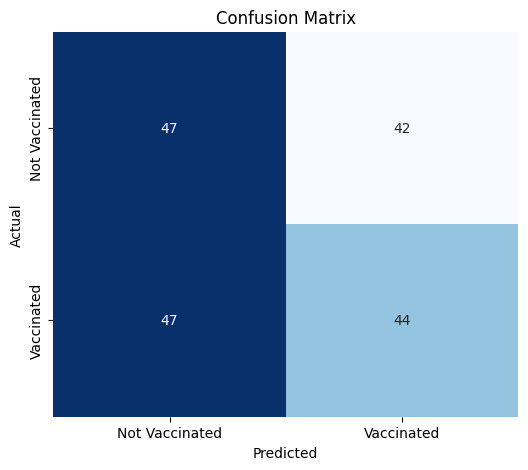


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.50      0.53      0.51        89
           1       0.51      0.48      0.50        91

    accuracy                           0.51       180
   macro avg       0.51      0.51      0.51       180
weighted avg       0.51      0.51      0.51       180



In [ ]:
# Evaluate the gradient boosting model for various metrics
evaluate(gbc, X_tr, X_te, y_tr, y_te)

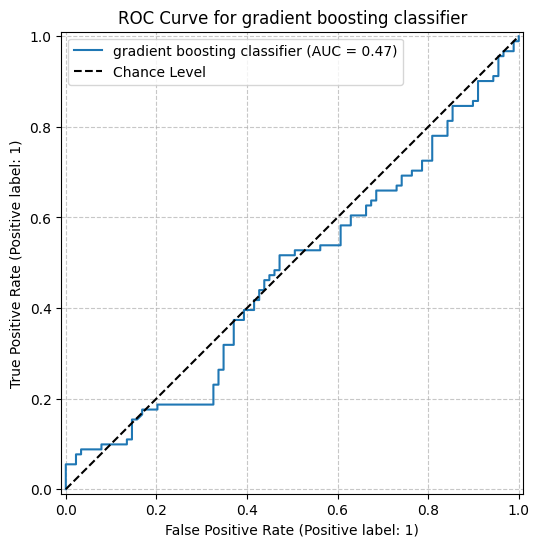

In [ ]:
# Plotting the roc-auc curve for the gradient boosting model
plot_roc_curve(gbc, X_te, y_te, name='gradient boosting classifier');

##MODEL 6: XG Boosting Classifier

In [ ]:
import xgboost

# Setting up the XG Boosting model to go through the pipeline
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgboost.XGBClassifier(learning_rate= 1, max_depth= 2, n_estimators= 100, random_state=42))
])

In [ ]:
# fitting the xg boosting model to the training data
xgb.fit(X_tr, y_tr)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('num_imputer',
                                                                   IterativeImputer(max_iter=100,
                                                                                    random_state=42)),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  ['h1n1_concern',
                                                   'h1n1_knowledge',
                                                   'behavioral_antiviral_meds',
                                                   'behavioral_avoidance',
                                                   'opinion_h1n1_vacc_effective',
                                                   'opinion_h1n1_risk']),
                                                 ('ohe',
                                                  Pipeline(steps=[('ohe_i...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=2, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

--- Training Metrics ---
Accuracy: 0.7472
Precision: 0.7433
Recall: 0.7637
F1-Score: 0.7534
ROC AUC: 0.8213

--- Test Metrics ---
Accuracy: 0.4889
Precision: 0.4949
Recall: 0.5385
F1-Score: 0.5158
ROC AUC: 0.4612

--- Confusion Matrix (Test Set) ---


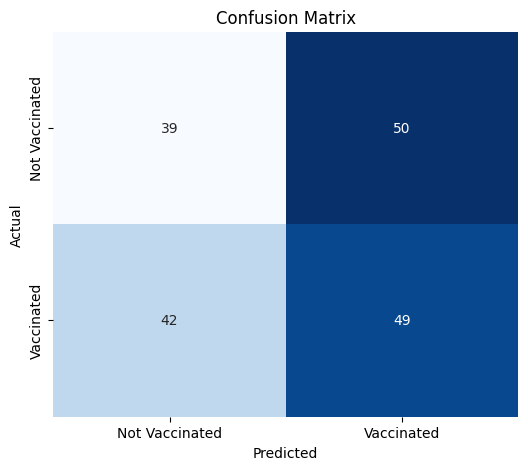


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.48      0.44      0.46        89
           1       0.49      0.54      0.52        91

    accuracy                           0.49       180
   macro avg       0.49      0.49      0.49       180
weighted avg       0.49      0.49      0.49       180



In [ ]:
# Evaluating the XG Boost model for various metrics
evaluate(xgb, X_tr, X_te, y_tr, y_te)

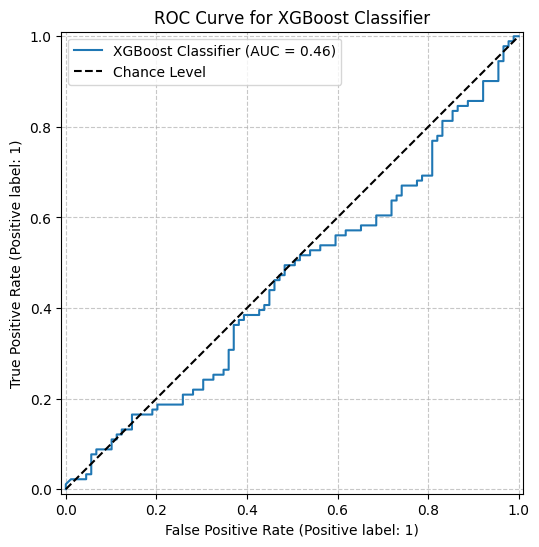

In [ ]:
plot_roc_curve(xgb, X_te, y_te, name='XGBoost Classifier');

#Comparison of Model ROC Curves

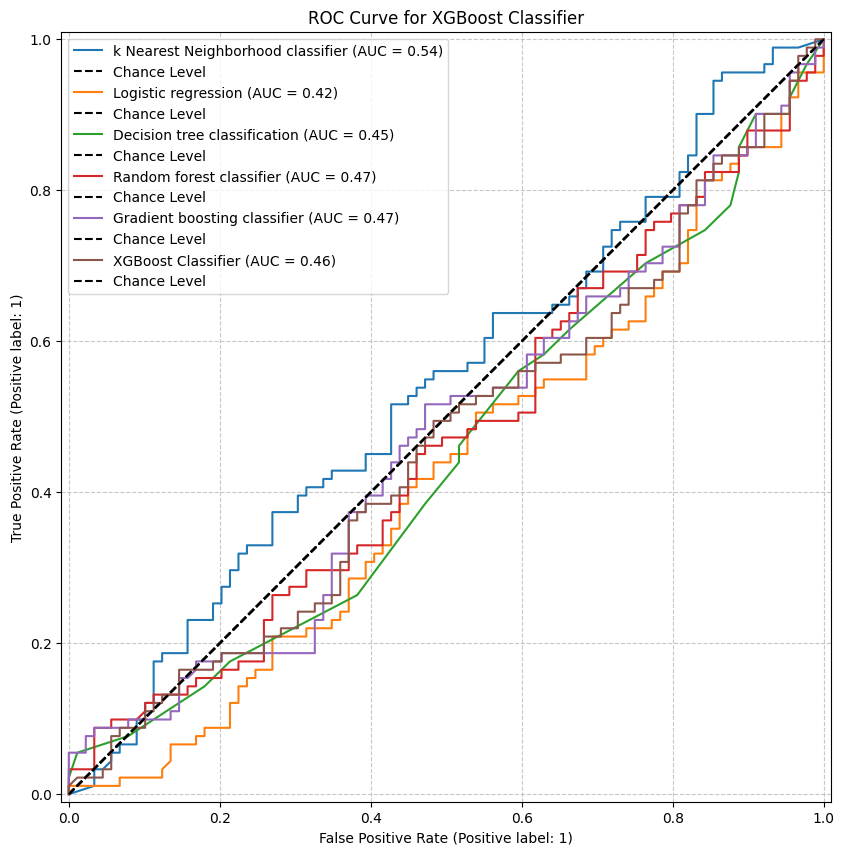

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))
#plot_roc_curve(dummy_model, X_te, y_te,
               #name='Dummy model', ax=ax)
plot_roc_curve(kNN, X_te, y_te,
               name='k Nearest Neighborhood classifier', ax=ax)
plot_roc_curve(logreg, X_te, y_te,
               name='Logistic regression', ax=ax)
plot_roc_curve(dtc, X_te, y_te,
               name='Decision tree classification', ax=ax)
plot_roc_curve(rfc, X_te, y_te,
               name='Random forest classifier', ax=ax)
plot_roc_curve(gbc, X_te, y_te,
               name='Gradient boosting classifier', ax=ax)
plot_roc_curve(xgb, X_te, y_te,
               name='XGBoost Classifier', ax=ax);

###'Final' Model: Gradient Boosting Classifier

In [ ]:
final_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(learning_rate =0.1, n_estimators=200,
                                              max_depth=5,
                                              random_state=42))
])

In [ ]:
output_final_model = final_model.fit(X_tr, y_tr)

--- Training Metrics ---
Accuracy: 1.0000
Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
ROC AUC: 1.0000

--- Test Metrics ---
Accuracy: 0.6100
Precision: 0.6111
Recall: 0.6471
F1-Score: 0.6286
ROC AUC: 0.5770

--- Confusion Matrix (Test Set) ---


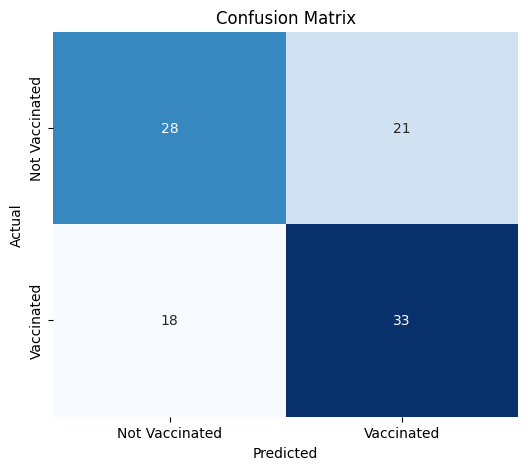


--- Classification Report (Test Set) ---
              precision    recall  f1-score   support

           0       0.61      0.57      0.59        49
           1       0.61      0.65      0.63        51

    accuracy                           0.61       100
   macro avg       0.61      0.61      0.61       100
weighted avg       0.61      0.61      0.61       100



In [ ]:
evaluate(final_model, X_tr, X_hold, y_tr, y_hold)

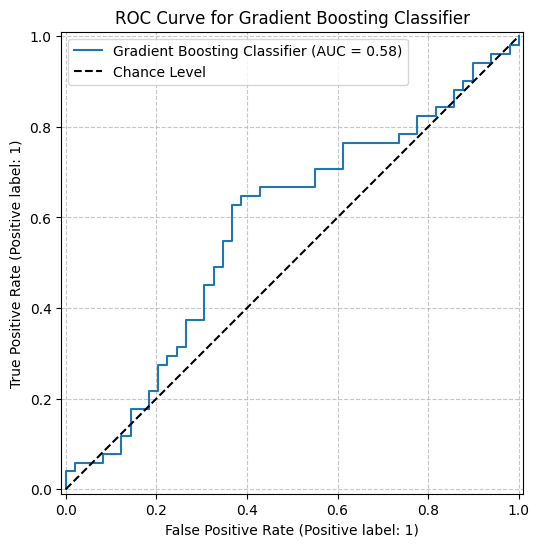

In [ ]:
plot_roc_curve(final_model, X_hold, y_hold, name='Gradient Boosting Classifier');

In [ ]:
# we can calculate predictions for confusion matrix
hold_preds_final_model = final_model.predict(X_hold)
cm=confusion_matrix(y_hold, hold_preds_final_model, normalize='true')

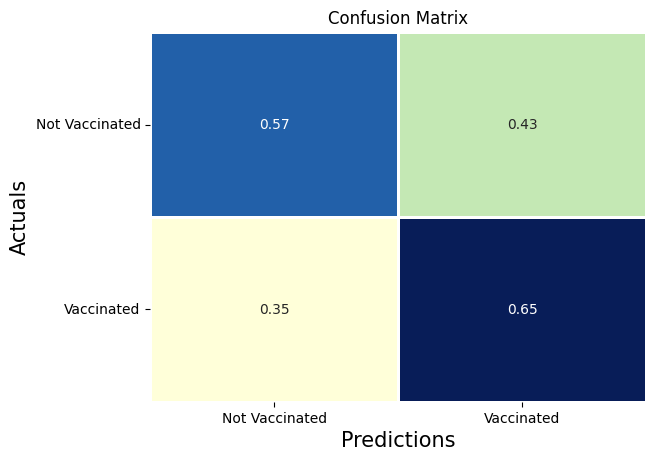

In [ ]:
# Plot heatmap for final model's confusion matrix for better visualization
ax= plt.subplot()
sns.heatmap(cm, annot=True, ax=ax, cbar=False, linewidths=1, cmap="YlGnBu");

ax.set_title('Confusion Matrix')
ax.set_xlabel('Predictions', fontsize = 15)
ax.set_ylabel('Actuals', fontsize = 15)
ax.xaxis.set_ticklabels(['Not Vaccinated', 'Vaccinated'])
ax.yaxis.set_ticklabels(['Not Vaccinated', 'Vaccinated'], rotation = 0, fontsize = 10);